# **ML Workflow**

## **ML Part**

1. Problem Statement
2. Data Gathering (using any method as below)
	- Webscraping
	- Extract from API
	- Extract from Dbs
	- Provided by stake holders
3. Data Assesment
	- Explore data using pandas method to get a glimpse of data
	- Identify & make a note of all the issues which needs to be cleaned
4. Data Cleaning
	- Perform cleaning
5. EDA
	- Perform EDA (uni, bi & multi)
	- Understand target column relation with all the cols
	- Identify if new features to be created
6. Data Transformation & Feature Engineering
	- Perform data transformation & feature engineering as understood in EDA
7. EDA & Hypothesis Testing
	- Perform another round of EDA after feature engieering
	- Perform hypothesis testings
8. Experiments
	- Base Model
	- Multi Model to find best model
	- HP Tuning
9. Create DVC Pipeline
	- Data Cleaning
	- Data PreProcessing
	- Data Transformation
	- Model Trainer
	- Model Evaluation
		- Log the model, regressor & transformed in mlflow
		- extract and save model path, run id in **run_information.json**
	- Model Registry
		- Add dvc remote s3: dvc remote add -d myremote **your_bucket_name**
		- dvc status
		- dvc push
		- Push model to model registry in Staging stage
		- model registry tracks the version & stages of model

10. Create FastAPI around the model
	- pydantic model for data validation & type conversion where possible
	- Uvicorn server which is faster then flask, we will get faster prediction
	- Perform sample tests/predictions on swagger UI locally

		```{
		"ID": "0x1",
		"Delivery_person_ID": "BANGRES11DEL01",
		"Delivery_person_Age": "30",
		"Delivery_person_Ratings": "4.8",
		"Restaurant_latitude": 12.9716,
		"Restaurant_longitude": 77.5946,
		"Delivery_location_latitude": 12.9352,
		"Delivery_location_longitude": 77.6245,
		"Order_Date": "2022-03-15",
		"Time_Orderd": "11:30",
		"Time_Order_picked": "11:45",
		"Weatherconditions": "Sunny",
		"Road_traffic_density": "High",
		"Vehicle_condition": 2,
		"Type_of_order": "Meal",
		"Type_of_vehicle": "motorcycle",
		"multiple_deliveries": "1",
		"Festival": "No",
		"City": "Metropolitian"
		}```

## **Ops part**

- **CI Pipeline**

**What to execute in CI/CD Pipeline**

- Pull data from DVC & Run DVC: `dvc pull` & `dvc repro`
- Execute performance tests on staged model against predefined thresholds (RMSE, R², MAE) and validate success criteria.
- If performance test succeeds, promote model from "Staging" to "Production" stage in MLflow Model Registry with performance metadata.
- If above tests pass, build Docker image, run Docker container and test the production model through API endpoints.
- Test production model via API endpoints (`/health`, `/predict`, `/docs`) for request/response validation, edge cases, and response time (<500ms) in Docker.
- Once all tests pass, push Docker image to ECR Repo.
- **Once Docker image is in ECR repo, we can deploy via CI/CD on:**
    1. EC2 using CodeDeploy (Configure ASG, Loadbalancer & Deployment method manually)
    2. ECS (Elastic Kubernetes service)
    3. EKS (Elastic Kubernetes service)

    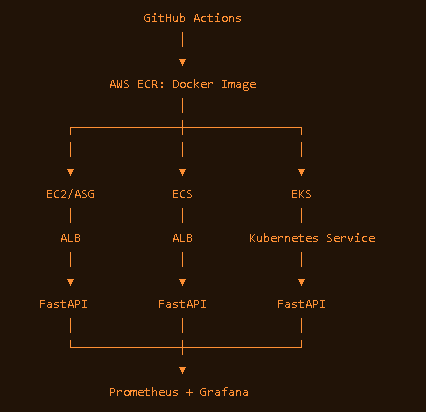

- Integrate Monitoring using ****Prometheus & Grafana****
- Integrate retraining using ****Airflow****

### 1. EC2 + ASG + LoadBalancer + CodeDeploy

1. **Define IAM roles**
    + **Launch Template**
    - roles > create role > ec2 service
    - AmazonEC2ContainerRegistryReadOnly
    - AmazonS3ReadOnlyAccess
    - AmazonEC2RoleforAWSCodeDeploy
    - **delivery_time_prediction_ec2_launchtemplate_role**

    + **CodeDeploy**
    - roles > create role > codedeploy
    - AWSCodeDeployRole (Pre Selected)
    - **delivery_time_prediction_codedeploy_role**

2. **Create launch template**
    - EC2 > launch templates > Create launch template
    - name: delivery-time-pred-template
    - version: version 1
    - check auto scaling guidance
    - quick start:
        - os: ubuntu
        - instance type: t2 micro
        - key_pair: ec2-docker-key
        - security group: select default
        - Advanced details > IAM instance profile > select: delivery_time_prediction_ec2_launchtemplate_role
        - paste user data script at the end
        - create launch template

3. **Create Auto Scaling group**
    - click on *Create Auto Scaling group*
    - name: delivery_time_prediction_asg
    - create 2 availability zones
    - Attach to a new load balancer > application load balancer > delivery-time-prediction-alb > internet facing
    - under listenders > create target group > delivery-time-prediction-tg
    - health checks: Turn on Elastic Load Balancing health checks
    - mention desired capacity as per requirements
    - select as per requirement: Target tracking scaling policy
    - Enable group metrics collection within CloudWatch
    - create auto scaling group
    - **wait for sometime if it says fail, It may take 2-3 mins**
    - check if agent is running on instance or not: sudo systemctl status codedeploy-agent

    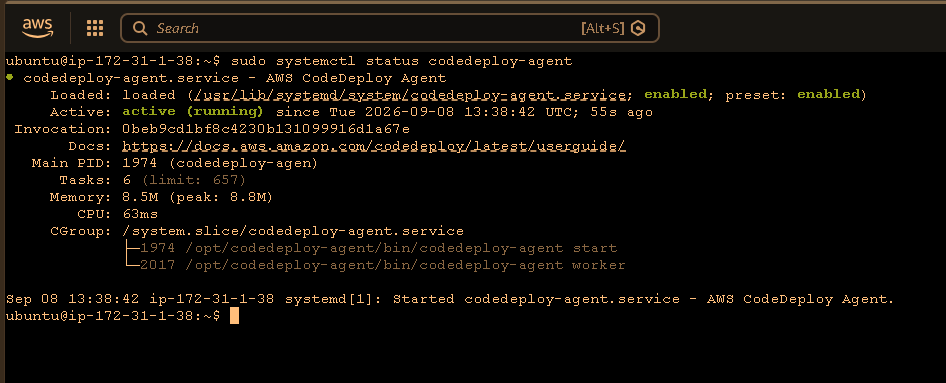

4. **Create CodeDeploy application**
    - CodeDeploy > Applications > create applications
    - name: deliverytimepredictionapp
    - compute platform: EC2/On-premises


5. **Create deployment group**
    - deployment group will be the auto scaling group
    - name: deliverytimepredictiondeploymentgroup
    - service role: delivery_time_prediction_codedeploy_role
    - deployment type:
        1. **In-place:** Updates the existing EC2 instances by stopping/replacing the current application version with the new version.
        2. **Blue/Green:** Deploys the new version to new EC2 instances, tests it, and then shifts traffic from the old environment to the new one. 
    - environment config: aws ec2 asg > select the one which we created above
    - deployment configuration: select as per requirement
    - select load balancer target group which we created above
    - create deployment group


6. create appspec.yaml file
    ```
    version: 0.0
    os: linux

    files:
    - source: /
        destination: /home/ubuntu/app

    hooks:
    BeforeInstall:
        - location: deploy/scripts/install_dependencies.sh
        timeout: 300
        runas: ubuntu

    ApplicationStart:
        - location: deploy/scripts/start_docker.sh
        timeout: 300
        runas: ubuntu
    ```


7. Create 2 files under deploy/scripts
    - install_dependencies.sh
    - start_docker.sh


8. Update CICD file to add deployment steps
    ```
      # # Zip the required files
      # - name: Zip files for deployment
      #   if: success()
      #   run: |
      #       zip -r deployment.zip appspec.yml deploy/scripts/install_dependencies.sh deploy/scripts/start_docker.sh


      # # Upload the ZIP file to S3
      # - name: Upload ZIP to S3
      #   if: success()
      #   run: |
      #       aws s3 cp deployment.zip s3://deliverytimepredictiondeployment/deployment.zip

            
      # # Deploy to AWS CodeDeploy using the uploaded ZIP file
      # - name: Deploy to AWS CodeDeploy
      #   if: success()
      #   run: |
      #       aws configure set DAGSHUB_USERNAME ${{ secrets.DAGSHUB_USERNAME }}
      #       aws configure set DAGSHUB_TOKEN  ${{ secrets.DAGSHUB_TOKEN  }}
      #       aws deploy create-deployment \
      #       --application-name deliverytimeprediction \
      #       --deployment-config-name CodeDeployDefault.OneAtATime \
      #       --deployment-group-name deliverytimepredictiondeploymentgroup \
      #       --s3-location bucket=deliverytimepredictiondeployment,key=deployment.zip,bundleType=zip \
      #       --file-exists-behavior OVERWRITE \
      #       --region ap-south-1

    ```
    
    - CICD will now handle the deployment, no need to do manually
    - create seperate s3 bucket to upload the zip file

7. run **dvc repro --force** and git push to trigger cicd pipeline

### 2. ECS

### 3. EKS